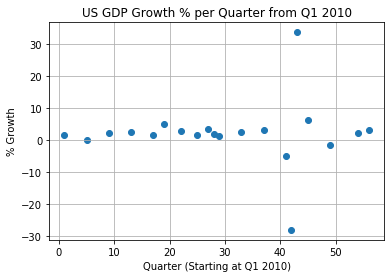

In [54]:
###CURVE FITTING AND INTERPOLATION PROJECT

##Intro
#For this project, we will be analyzing US GDP growth data. Each data point represents a % GDP Growth from the previous yearly
#quarter, quarter by quarter from 2010 to Q4 2024. The goal of this project is to analyze methods for curve fitting and
#interoplation of missing data points, in order to determine the strenghts and weaknesses of each method in terms of
#accuracy, smoothness, and other predictive factors.

#We will analyze 3 methods for interpolation and prediction: A cublic spline, a 4th degree least-squares fit, and a linear fit.

#The data is stored in the following arrays - y representing the GDP growth percantage a given quarter, and x representing the quarter, starting from Q1 2010, Q2 2010, etc.

import numpy as np
import matplotlib.pyplot as plt

y = np.array([1.7, 0.1, 2.4, 2.7, 1.7, 5, 3, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)
x = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56], dtype=float)

#Here's what the data looks like graphed:

plt.scatter(x,y,label="Data Points")
plt.title("US GDP Growth % per Quarter from Q1 2010")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("% Growth")
plt.grid(True)

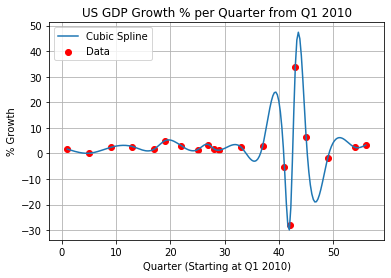

In [61]:
##PART A - CUBIC SPLINE INTERPOLATION

#We can use a cubic spline interpolation to try and map out trends and fill in gaps in data.
#Here is our cubic spline function:

def cubic_spline(x, y, num_points=200):
    #Data
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    #Number of data points
    n = len(x)     
    #Interval sizes between consecutive x values
    h = np.diff(x)            

    #Arrays for the tridiagonal system to solve for second derivatives
    A = np.zeros(n)
    B = np.zeros(n) 
    C = np.zeros(n)  
    D = np.zeros(n) 

    #Natural spline boundary conditions
    #(this makes the second derivative at the endpoints zero which smooths out the spline at the edges.)
  
    B[0] = 1
    B[-1] = 1
    D[0] = 0
    D[-1] = 0

    #For continuity, function, first, and second derivatives must be equal at each point.
    
    #This builds the tridiagonal system
    for i in range(1, n - 1):
        A[i] = h[i - 1]                       
        B[i] = 2 * (h[i - 1] + h[i])    
        C[i] = h[i]                           
        D[i] = 6 * ((y[i + 1] - y[i]) / h[i] -      
                    (y[i] - y[i - 1]) / h[i - 1])

    #Forward elimination for solving tridiagonal system
    for i in range(1, n):
        w = A[i] / B[i - 1]       
        B[i] -= w * C[i - 1]    
        D[i] -= w * D[i - 1]     

    #Back substitution 
    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]
    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    #This defines a function to evaluate the spline at any x value
    def evaluate(x_eval):
        for i in range(n - 1):
            if x[i] <= x_eval <= x[i + 1]:   
                h_i = x[i + 1] - x[i]
                a = (x[i + 1] - x_eval) / h_i
                b = (x_eval - x[i]) / h_i

                #Cubic spline formula using linear combination of y-values and M's
                return (
                    (a**3 - a) * M[i] * (h_i**2) / 6 +
                    (b**3 - b) * M[i + 1] * (h_i**2) / 6 +
                    a * y[i] +
                    b * y[i + 1]
                )
        return None

    #This generates smooth x and y values for plotting the spline
    x_smooth = np.linspace(x[0], x[-1], num_points)
    y_smooth = np.array([evaluate(xi) for xi in x_smooth])

    return x_smooth, y_smooth
#Let's plot, and see how our spline fits!

x_smooth, y_smooth = cubic_spline(x, y)

plt.figure()
plt.plot(x_smooth, y_smooth, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data")
plt.legend()
plt.title("US GDP Growth % per Quarter from Q1 2010")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("% Growth")
plt.grid(True)
plt.show()

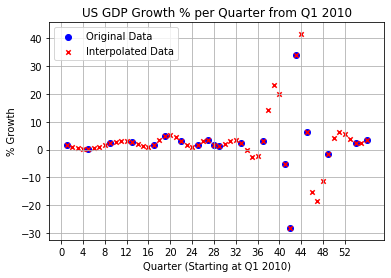

In [36]:
#The data goes through every point, but creates large oscillations around outliers.

#Let's use our spline to interpolate the missing data points for all the full quarterly values.

#All 56 points!
x_full = np.arange(1, 57)

#y values, filling in missing values with spline:
_, y_full = cubic_spline(x, y, num_points=56)

#plot!
plt.figure()
plt.scatter(x, y, color='blue', label="Original Data")
plt.scatter(x_full, y_full, color='red', s=20, marker='x', label="Interpolated Data")
plt.legend()
plt.title("US GDP Growth % per Quarter from Q1 2010")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("% Growth")
plt.grid(True)
plt.xticks(np.arange(0, 56, 4))
plt.show()


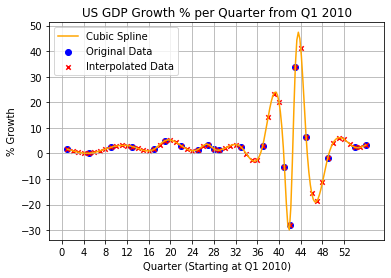

In [38]:
#With cubic spline visible:

plt.figure()
plt.plot(x_smooth, y_smooth, color = 'orange', label="Cubic Spline")
plt.scatter(x, y, color='blue', label="Original Data")
plt.scatter(x_full, y_full, color='red', s=20, marker='x', label="Interpolated Data")
plt.legend()
plt.title("US GDP Growth % per Quarter from Q1 2010")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("% Growth")
plt.grid(True)
plt.xticks(np.arange(0, 56, 4))
plt.show()

In [39]:
#The interpolant seems fairly reasonable in lieu of the orignal points. 
#While the magnitudes of the covid disturbances are genrally reasonable, 
#sometimes the interpolation implies even more drastic economic shifts compared to the original data.

#The Runge phenomenon describes how high-degree polynomials can create exaggerated oscilations in the data, 
#meaning although the spline naturally crosses every data point and might represent extremes well (such as Q2 2020/42), 
#some emptier sections have approximations that seem extreme and variable - such as 38-40, or 46-48.

#Smoothed splines or weighted least squares functions trade perfect data precision (especially for extreme values) for 
#smoother, less oscillatory interpolations subject to Runge. I think using one of these functions across the whole dataset would 
#fail to properly represent covid instability, but perhaps zooming in on said instabilities would 
#allow these types of functions to make steadier and more reasonable interpolations of the gaps in the extreme sections.

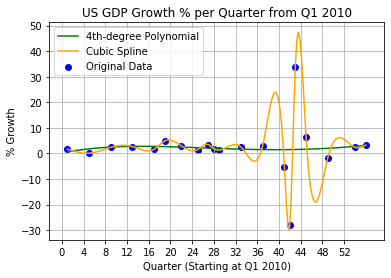

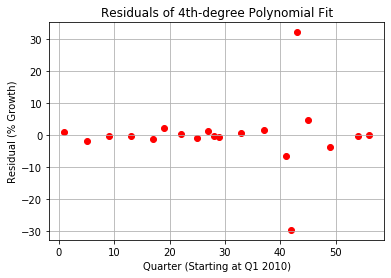

4th-degree polynomial RMSE: 10.0314


In [82]:
##Part B — Polynomial & Least Squares Comparison

#Let's create a function for a 4th-degree polynomial fit using a vandermonde matrix.

def poly4_fit_vandermonde(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    #Build Vandermonde matrix for 4th degree
    
    n=x.size
    V = np.zeros((n, 5))
    V[:, 0] = x**4
    V[:, 1] = x**3
    V[:, 2] = x**2
    V[:, 3] = x
    V[:, 4] = 1
    
    #Solve least squares problem:
    coeffs, _, _, _ = np.linalg.lstsq(V, y, rcond=None)
    
    return coeffs


#Creating the 4th degree function
coeffs = poly4_fit_vandermonde(x, y)
x_fd = np.linspace(x[0], x[-1], 200)
y_fd = np.zeros_like(x_smooth, dtype=float)
degree = len(coeffs) - 1
for i, a in enumerate(coeffs):
    y_fd += a * x_smooth**(degree - i)
    
#let's plot it against the data and the cubic spline to compare!

plt.figure()
plt.plot(x_fd, y_fd, color = 'green', label="4th-degree Polynomial")
plt.scatter(x, y, color='blue', label="Original Data")
plt.plot(x_smooth, y_smooth, color = 'orange', label="Cubic Spline")
plt.grid(True)
plt.legend()
plt.title("US GDP Growth % per Quarter from Q1 2010")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("% Growth")
plt.xticks(np.arange(0, 56, 4))
plt.show()

# Compute residuals
y_pred = np.zeros_like(x, dtype=float)
for i, a in enumerate(coeffs):
    y_pred += a * x**(4 - i)
    
residuals = y - y_pred

# Plot residuals
plt.figure()
plt.scatter(x, residuals, color='red')
plt.grid(True)
plt.title("Residuals of 4th-degree Polynomial Fit")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.ylabel("Residual (% Growth)")
plt.show()

#RSME
n=x.size
V = np.zeros((n, 5))
V[:, 0] = x**4
V[:, 1] = x**3
V[:, 2] = x**2
V[:, 3] = x
V[:, 4] = 1
y_pred = V @ coeffs

residuals = y - y_pred
rmse = np.sqrt(np.mean(residuals**2))
print(f"4th-degree polynomial RMSE: {rmse:.4f}")

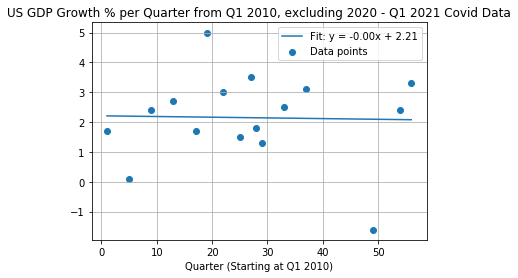

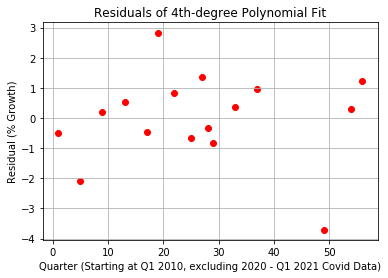

RMSE of linear fit: 1.4439


In [75]:
#The 4th degree polynomial is very flat compared to the cubic spline, as well as certain data points. It doesn't accurately
#represent covid data, and interpolates it as very smooth, like pre-and post covid data which it predicts fine.
#Outside covid data, residuals remain under 5 percent. Covid spikes that to around 30 in some cases, demonstrating
#the discrepancy between the ability for this polynomial to fit smoother data vs outliers. RSME is around 10%, showing
#how the accuracy of the function is skewed by outliers in the graph. However, it doesn't oscilate wildly, meaning some of the 
#interpolated points between the covid data appear a somewhat more reasonable compared to what the spline's 
#runge effect predicts, and some residuals remain under 10% in this section.

#Let's try a linear least squares regression, excluding covid data (41-45) since outliers like that can significantly 
#reduce the linearity of the data.
#Indices to remove from data:
indices = [13, 14, 15, 16]

#New arrays
x_noCovid = np.delete(x, indices)
y_noCovid = np.delete(y, indices)

def Least_Squares(X,Y):
    m = (X.size*np.sum(X*Y)-np.sum(X)*np.sum(Y))/(X.size*np.sum(X**2)-(np.sum(X)**2)) #minimize least squares
    b = (np.sum(Y) - m*np.sum(X))/(X.size)
    return m, b

#find the line
m, b = Least_Squares(x_noCovid, y_noCovid)

#generate fitted line
x_fit = np.linspace(min(x_noCovid), max(x_noCovid), 200)
y_fit = m * x_fit + b

#plot!
plt.scatter(x_noCovid, y_noCovid, label="Data points")
plt.plot(x_fit, y_fit, label=f"Fit: y = {m:.2f}x + {b:.2f}")
plt.grid(True)
plt.legend()
plt.title("US GDP Growth % per Quarter from Q1 2010, excluding 2020 - Q1 2021 Covid Data")
plt.xlabel("Quarter (Starting at Q1 2010)")
plt.show()

#residuals:
y_pred = m * x_noCovid + b
residuals = y_noCovid - y_pred

plt.figure()
plt.scatter(x_noCovid, residuals, color='red')
plt.grid(True)
plt.title("Residuals of 4th-degree Polynomial Fit")
plt.xlabel("Quarter (Starting at Q1 2010, excluding 2020 - Q1 2021 Covid Data)")
plt.ylabel("Residual (% Growth)")
plt.show()

#RSME
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE of linear fit: {rmse:.4f}")

In [ ]:
#As we can see, the trendline slop is almost 0, and slightly negative. The RSME is around 1.4%, an order of magnitude smaller
#than the 4th degree model that includes covid data, a significant improvement. The non-covid linear model doesn't have 
#any residuals above 4%, so it might be fairly accurate for this stretch of time. However, using a linear least-squares 
#model only makes sense when disregarding large short term shocks like covid , and assumes a linear relationship for 
#economic growth (typically, at least over long stretches of time, economies grow exponentially).

In [ ]:
##Part C — Method Justification

#If a policymaker wanted to interpolate between two known point of GDP growth, the best method depends on where and between
#what points the interpolation is made. For a gap during a relatively smooth period, 4th degree or even linear regressions
#are sufficient - their residuals remain low here, as we have shown. Cubic splines can work fine, but the closer to outliers
#an interpolation is, the more wild oscillations in the spline can get. For those moments of shock and turbulence, only
#a spline can create more reasonable interpolations, as the residuals of smoother methods become extremely high - 
#accuracy degrades. Still, the more "in the middle" of a gap you interpolate - and the wider and steeper the gap is -
#the more the spline's oscillations dominate the prediction. A spline can make reasonable interpolations very close to known
#data points that are outliers, but as implied before, the edges of an economic shock are still predicted somewhat 
#accurately by smoother curves.

#Of the three methods explored here, I would reccomend a 4th degree polynomial for overall flexibility in interpolation. 
#Linear regressions have little flexibility, and it's not always correct to assume a linear relationship in the data. 
#Cubic splines seem like they work fine in both steeper and shallower gaps, but depending on the width and steepness of 
#the gap, splines can introduce very erratic predictions due to the runge effect. Though 4th degree polynomials might not 
#accurately predict outlying values, they have reasonable residuals and less erratic predictions than splines in the lead up
#and follow up to said outliers, ergo they're more useful for interpolating the data in most circumstances.

In [ ]:
##CONCLUSION

#The three different methods for interpolation/trend analysis different in relative effectiveness for each task.
#The linear regression was reasonable for mapping long term linear trends, irrespective of outlying moments. In this case,
#the tiny slope showed that overall growth was negligible. Outside of outliers, residuals were reasonable. The 4th degree
#polynomial was slightly better in terms of residual values outside of outliers, as well as around the edges of an outlying
#market event. It is particularly useful for interpolation in these conditions - where more drastic predictors like splines
#begin to fail. Finally, splines made sense for interpolating data immediately around outlying points, though oscillation 
#can create very non-smooth prediction.